# TP -- Dérivées, gradients... et le Mont-Blanc

Dans ce TP, nous allons manipuler les notions de **dérivée** et de **gradient** vues en cours, non pas sur des fonctions inventées, mais sur une **vraie carte d'altitude du massif du Mont-Blanc**.

L'intérêt est que tout le vocabulaire du cours est en fait du vocabulaire de montagne:

| Cours | Montagne |
|---|---|
| la dérivée $f'(x)$ | la **pente** (les $8\%$ des panneaux routiers) |
| le gradient $\nabla f(\vec{x})$ | la ligne de **plus grande pente** |
| sa norme $\| \nabla f(\vec{x}) \|$ | la **raideur** de la pente |
| un **maximum local** | un **sommet** |
| un **minimum local** | une **cuvette**, un lac |
| un **point selle** | un **col** |
| la direction $-\nabla f(\vec{x})$ | le chemin que suit une **goutte d'eau** |

À la fin du TP, votre code aura retrouvé tout seul les sommets du massif, et fait ruisseler des gouttes d'eau jusque dans la vallée de Chamonix.

## Librairies

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import maximum_filter, gaussian_filter

plt.rcParams["figure.figsize"] = (9, 6)

## 0. Les données: une carte d'altitude réelle

Le fichier `data/mont_blanc.npz` contient un **modèle numérique de terrain** (MNT) issu de la mission spatiale **SRTM** de la NASA (données publiques, résolution 1 seconde d'arc, soit environ 30 m).

C'est un tableau `numpy` de nombres: `altitude[i, j]` est l'altitude en mètres du point situé sur la ligne `i` et la colonne `j`.

Autrement dit, c'est exactement une fonction
$$
f : \mathbb{R}^2 \longrightarrow \mathbb{R}, \qquad f(x, y) = \text{altitude au point } (x,y),
$$
mais connue seulement en un nombre fini de points (une **grille**).

Attention à deux choses:

- la ligne `0` est au **sud** et la ligne du haut au **nord**: l'axe $y$ est donc orienté vers le nord, comme en maths;
- un pixel ne fait **pas** la même largeur que sa hauteur: `dx` mètres horizontalement (est-ouest) et `dy` mètres verticalement (nord-sud). Nous en aurons besoin pour calculer des pentes correctes.

In [2]:
data = np.load("data/mont_blanc.npz")

Z   = data["altitude"].astype(float)   # altitudes en mètres
lat = data["lat"]                      # latitude de chaque ligne
lon = data["lon"]                      # longitude de chaque colonne
dx  = float(data["dx"])                # largeur d'un pixel, en mètres (est-ouest)
dy  = float(data["dy"])                # hauteur d'un pixel, en mètres (nord-sud)

print("forme du tableau :", Z.shape)
print("altitude min : %.0f m   max : %.0f m" % (Z.min(), Z.max()))
print("taille d'un pixel : dx = %.2f m,  dy = %.2f m" % (dx, dy))
print("source :", data["source"])

forme du tableau : (542, 722)
altitude min : 972 m   max : 4797 m
taille d'un pixel : dx = 21.49 m,  dy = 30.87 m
source : SRTM 1 arc-sec (~30 m) - NASA/USGS, via AWS Terrain Tiles (elevation-tiles-prod), tuile N45E006. Domaine public.


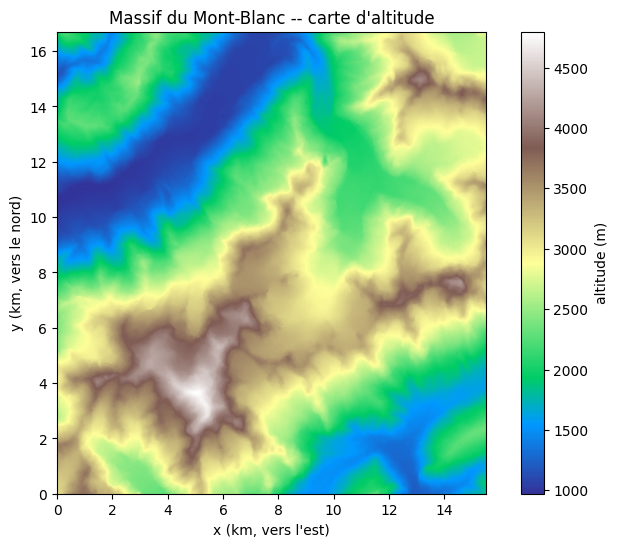

In [18]:
# largeur et hauteur de la zone, en kilomètres
W = (Z.shape[1] - 1) * dx / 1000
H = (Z.shape[0] - 1) * dy / 1000
extent = [0, W, 0, H]     # pour que matplotlib affiche des kilomètres

plt.imshow(Z, origin="lower", extent=extent, cmap="terrain")
plt.colorbar(label="altitude (m)")
plt.xlabel("x (km, vers l'est)")
plt.ylabel("y (km, vers le nord)")
plt.title("Massif du Mont-Blanc -- carte d'altitude")
plt.show()

<div class="alert alert-block alert-info">

**Exercice 0.1 -- le toit de l'Europe**

Retrouvez le point le plus haut de la carte.

- Utilisez `Z.argmax()` puis `np.unravel_index(...)` pour obtenir la ligne `i` et la colonne `j` du maximum.
- Affichez son altitude, ainsi que sa latitude `lat[i]` et sa longitude `lon[j]`.
- Vérifiez sur une carte (ou avec vos souvenirs de géographie) de quel sommet il s'agit.

</div>

In [19]:
i, j = np.unravel_index(Z.argmax(), Z.shape)

print("altitude maximale : %.0f m" % Z[i, j])
print("position : ligne %d, colonne %d" % (i, j))
print("latitude %.4f, longitude %.4f" % (lat[i], lon[j]))
print()
print("-> c'est le Mont Blanc (4808 m dans la réalité).")

altitude maximale : 4797 m
position : ligne 118, colonne 234
latitude 45.8327, longitude 6.8649

-> c'est le Mont Blanc (4808 m dans la réalité).


## 1. La dérivée: le taux d'accroissement

Rappel du cours: la dérivée de $f$ au point $x$ est la limite du **taux d'accroissement**

$$
f'(x) = \lim_{h \rightarrow 0} \frac{f(x+h) - f(x)}{h}.
$$

Un ordinateur ne sait pas calculer une limite. Il ne sait faire qu'une chose: prendre un $h$ **petit mais non nul**, et calculer le quotient. C'est ce qu'on appelle une **différence finie**.

Commençons par une fonction que vous connaissez bien, celle du cours:
$$
f(x) = x^3 - 3x, \qquad f'(x) = 3x^2 - 3.
$$
Comme nous connaissons ici la dérivée exacte, nous allons pouvoir **mesurer l'erreur** commise par l'ordinateur.

In [20]:
def f(x):
    return x**3 - 3*x

def f_prime_exacte(x):
    return 3*x**2 - 3

<div class="alert alert-block alert-info">

**Exercice 1.1 -- coder la définition de la dérivée**

Écrivez une fonction `derivee(f, x, h)` qui renvoie le taux d'accroissement
$\dfrac{f(x+h) - f(x)}{h}$.

Testez-la en $x = 2$ avec $h = 10^{-6}$, et comparez avec `f_prime_exacte(2)` (qui vaut $9$).

</div>

In [21]:
def derivee(f, x, h):
    return (f(x + h) - f(x)) / h

x0 = 2.0
approx = derivee(f, x0, 1e-6)
exacte = f_prime_exacte(x0)

print("approximation : %.10f" % approx)
print("valeur exacte : %.10f" % exacte)
print("erreur        : %.2e" % abs(approx - exacte))

approximation : 9.0000060018
valeur exacte : 9.0000000000
erreur        : 6.00e-06


<div class="alert alert-block alert-info">

**Exercice 1.2 -- quel $h$ faut-il choisir?**

En maths, plus $h$ est petit, meilleure est l'approximation. Vérifions-le sur machine.

- Pour $h = 10^{-1}, 10^{-2}, \dots, 10^{-16}$, calculez l'erreur $|\,\texttt{derivee}(f, 2, h) - f'(2)\,|$.
- Tracez cette erreur en fonction de $h$ avec `plt.loglog` (échelle logarithmique sur les deux axes).
- **Que se passe-t-il?** Le résultat est-il celui que vous attendiez?

</div>

h = 1e-01   erreur = 6.100e-01
h = 1e-02   erreur = 6.010e-02
h = 1e-03   erreur = 6.001e-03
h = 1e-04   erreur = 6.000e-04
h = 1e-05   erreur = 6.000e-05
h = 1e-06   erreur = 6.002e-06
h = 1e-07   erreur = 5.848e-07
h = 1e-08   erreur = 5.470e-08
h = 1e-09   erreur = 7.447e-07
h = 1e-10   erreur = 7.447e-07
h = 1e-11   erreur = 7.447e-07
h = 1e-12   erreur = 8.001e-04
h = 1e-13   erreur = 1.163e-02
h = 1e-14   erreur = 2.371e-01
h = 1e-15   erreur = 1.006e+00
h = 1e-16   erreur = 9.000e+00


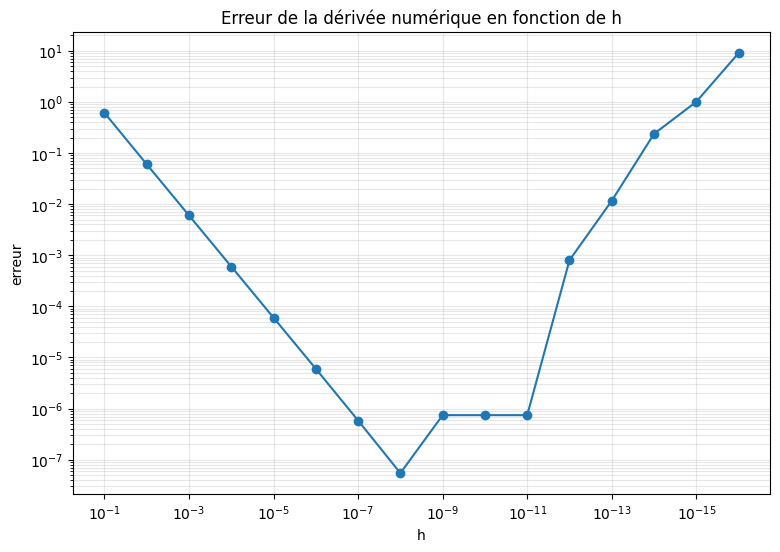

In [22]:
H = 10.0 ** np.arange(-1, -17, -1)
erreurs = [abs(derivee(f, 2.0, h) - f_prime_exacte(2.0)) for h in H]

for h, e in zip(H, erreurs):
    print("h = %.0e   erreur = %.3e" % (h, e))

plt.loglog(H, erreurs, "o-")
plt.gca().invert_xaxis()
plt.xlabel("h")
plt.ylabel("erreur")
plt.title("Erreur de la dérivée numérique en fonction de h")
plt.grid(True, which="both", alpha=0.3)
plt.show()

<div class="alert alert-block alert-warning">

**Question.** Décrivez la courbe obtenue. Quel est le $h$ optimal? Pourquoi l'erreur **remonte-t-elle** quand $h$ devient très petit?

</div>

**Réponse.**

La courbe a une forme de **V**.

- À droite (grand $h$), l'erreur diminue quand $h$ diminue: c'est le comportement mathématique attendu, le taux d'accroissement se rapproche de la limite. C'est l'**erreur de troncature**.
- À gauche (très petit $h$), l'erreur **remonte**. En effet $f(x+h)$ et $f(x)$ deviennent deux nombres presque identiques; en les soustrayant, on perd presque tous les chiffres significatifs, puis on divise ce résidu par un $h$ minuscule, ce qui amplifie l'erreur. C'est l'**erreur d'arrondi** de la virgule flottante.
- L'optimum est autour de $h \approx 10^{-8}$, c'est-à-dire environ $\sqrt{\varepsilon}$ où $\varepsilon \approx 2 \cdot 10^{-16}$ est la précision machine des `float`.

Moralité: **prendre $h$ le plus petit possible est une mauvaise idée sur un ordinateur.** La limite mathématique et le calcul machine ne sont pas la même chose.

### Un profil d'altitude réel

Passons aux vraies données. Nous prenons une **coupe verticale** de la carte: la colonne qui passe par le sommet du Mont Blanc. On obtient une fonction d'une seule variable
$$
p(y) = \text{altitude le long de cette ligne},
$$
c'est-à-dire exactement le **profil** que l'on voit sur les topos de randonnée.

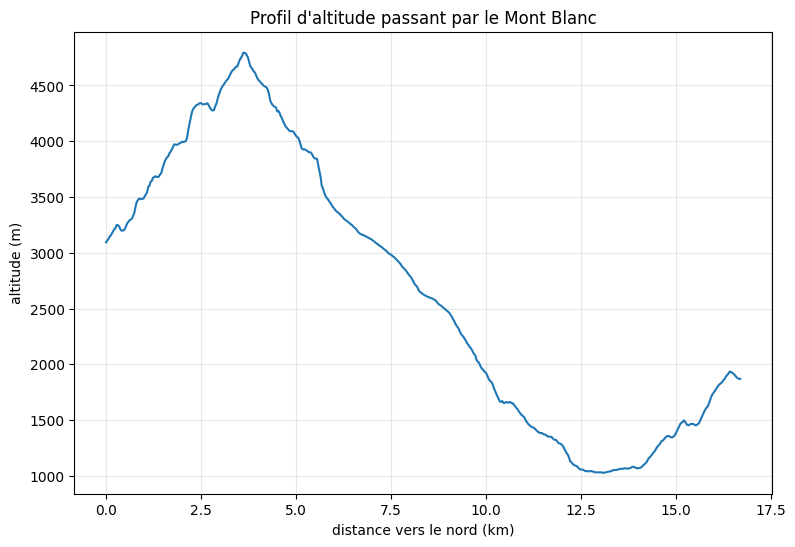

In [24]:
j_coupe = int(np.argmin(abs(lon - 6.8652)))    # colonne du Mont Blanc
profil  = Z[:, j_coupe]                        # altitudes le long de cette colonne
y       = np.arange(len(profil)) * dy          # distance en mètres, du sud vers le nord

plt.plot(y / 1000, profil)                     # on divise par 1000 pour avoir des kilomètres  
plt.xlabel("distance vers le nord (km)")
plt.ylabel("altitude (m)")
plt.title("Profil d'altitude passant par le Mont Blanc")
plt.grid(alpha=0.3)
plt.show()

<div class="alert alert-block alert-info">

**Exercice 1.3 -- la pente en pourcentage**

Ici, pas de formule: nous n'avons qu'un tableau de valeurs. La dérivée se calcule donc par différences finies:
$$
p'(y_i) \approx \frac{p(y_{i+1}) - p(y_{i-1})}{2 \, \texttt{dy}}
\qquad \text{(différence \emph{centrée})}.
$$

- Calculez cette dérivée avec `np.gradient(profil, dy)` (qui fait exactement ce calcul pour vous).
- Tracez-la sous le profil.
- La **pente en pourcentage** d'une route est $100 \times |p'|$. Calculez la pente maximale du profil et comparez-la à un panneau routier (un col routier dépasse rarement $12\%$).

</div>

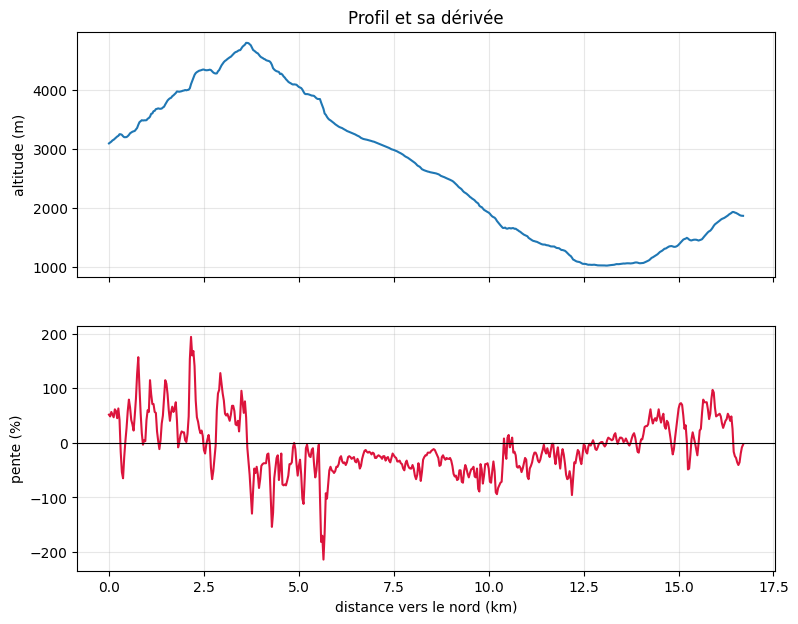

pente maximale le long du profil : 214 %
(un col routier dépasse rarement 12 %)


In [28]:
pente = np.gradient(profil, dy)          # dérivée du profil

fig, (a1, a2) = plt.subplots(2, 1, sharex=True, figsize=(9, 7))
a1.plot(y / 1000, profil)
a1.set_ylabel("altitude (m)")
a1.set_title("Profil et sa dérivée")
a1.grid(alpha=0.3)

a2.plot(y / 1000, 100 * pente, color="crimson")
a2.axhline(0, color="k", lw=0.8)
a2.set_xlabel("distance vers le nord (km)")
a2.set_ylabel("pente (%)")
a2.grid(alpha=0.3)
plt.show()

print("pente maximale le long du profil : %.0f %%" % (100 * abs(pente).max()))
print("(un col routier dépasse rarement 12 %)")

## 2. Le gradient

Une carte d'altitude est une fonction de **deux** variables. Sa dérivée est donc un **vecteur**, le gradient:

$$
\nabla f(x,y) = \left( \begin{matrix} \dfrac{\partial f}{\partial x}(x,y) \\[2mm] \dfrac{\partial f}{\partial y}(x,y) \end{matrix} \right).
$$

`numpy` sait le calculer sur une grille avec `np.gradient(Z, dy, dx)`. Attention à l'ordre: le premier axe d'un tableau, c'est les **lignes** (donc $y$), le second les **colonnes** (donc $x$). La fonction renvoie donc les deux dérivées **dans cet ordre**.

<div class="alert alert-block alert-info">

**Exercice 2.1 -- carte des pentes**

- Calculez `gy, gx = np.gradient(Z, dy, dx)`.
- Calculez la norme du gradient $\|\nabla f\| = \sqrt{g_x^2 + g_y^2}$ (`np.hypot` le fait directement).
- Affichez-la avec `plt.imshow`. Où le terrain est-il le plus raide? Reconnaissez-vous des structures?

</div>

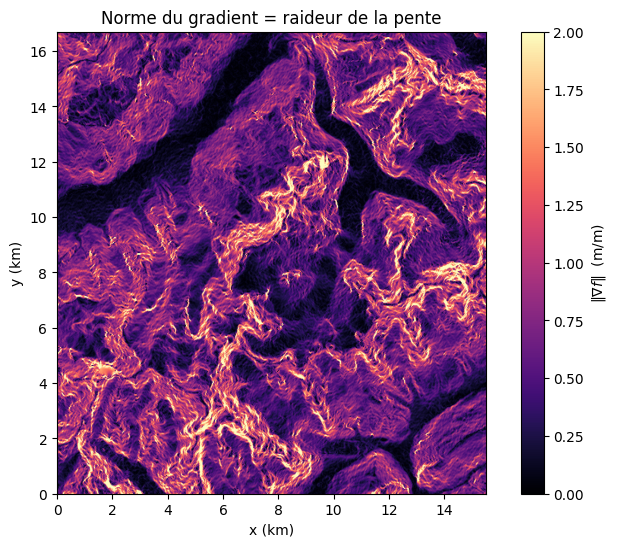

pente moyenne : 0.68  (soit 34°)
pente maximale: 6.04  (soit 81°)

Les zones sombres sont plates : les glaciers et le fond de la vallée de Chamonix.
Les zones claires sont les parois et les arêtes.


In [29]:
gy, gx = np.gradient(Z, dy, dx)     # attention: lignes (y) d'abord, colonnes (x) ensuite
norme  = np.hypot(gx, gy)           # sqrt(gx**2 + gy**2)

plt.imshow(norme, origin="lower", extent=extent, cmap="magma", vmax=2)
plt.colorbar(label=r"$\|\nabla f\|$  (m/m)")
plt.xlabel("x (km)"); plt.ylabel("y (km)")
plt.title("Norme du gradient = raideur de la pente")
plt.show()

print("pente moyenne : %.2f  (soit %.0f°)" % (norme.mean(), np.degrees(np.arctan(norme.mean()))))
print("pente maximale: %.2f  (soit %.0f°)" % (norme.max(),  np.degrees(np.arctan(norme.max()))))
print()
print("Les zones sombres sont plates : les glaciers et le fond de la vallée de Chamonix.")
print("Les zones claires sont les parois et les arêtes.")

<div class="alert alert-block alert-info">

**Exercice 2.2 -- le théorème du cours, en image**

Le cours affirme que le gradient pointe dans la **direction de plus grande pente ascendante**. Une conséquence visuelle: le gradient est toujours **perpendiculaire aux courbes de niveau**.

Vérifions-le sur un zoom autour du sommet.

- Tracez les courbes de niveau du zoom avec `plt.contour`.
- Superposez les vecteurs gradient avec `plt.quiver` (n'affichez qu'un point sur 8, sinon c'est illisible).
- Les flèches sont-elles perpendiculaires aux courbes? Pointent-elles vers le haut ou vers le bas?

</div>

In [30]:
# fenêtre de zoom autour du sommet du Mont Blanc
i0, i1, j0, j1 = 60, 180, 175, 295
s = 8      # on n'affiche qu'un vecteur sur 8

Zz  = Z[i0:i1, j0:j1]
gxz = gx[i0:i1, j0:j1]
gyz = gy[i0:i1, j0:j1]

xz = np.arange(j0, j1) * dx / 1000
yz = np.arange(i0, i1) * dy / 1000
XZ, YZ = np.meshgrid(xz, yz)

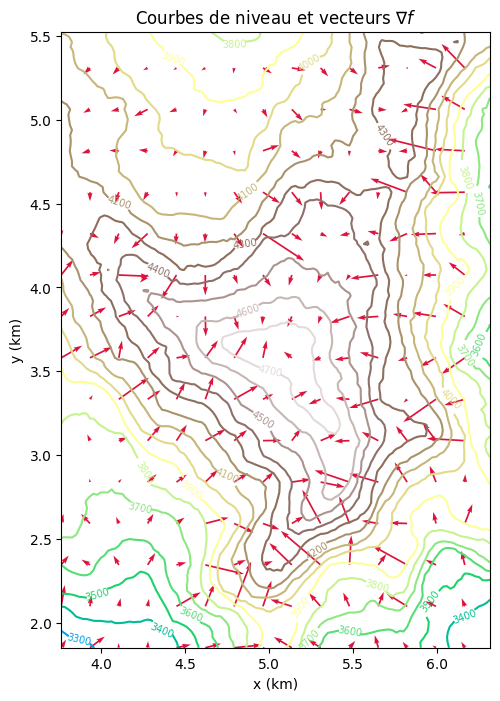

In [31]:
plt.figure(figsize=(9, 8))
cs = plt.contour(XZ, YZ, Zz, levels=np.arange(3000, 4900, 100), cmap="terrain")
plt.clabel(cs, inline=True, fontsize=7, fmt="%.0f")

plt.quiver(XZ[::s, ::s], YZ[::s, ::s], gxz[::s, ::s], gyz[::s, ::s],
           color="crimson", angles="xy")

plt.gca().set_aspect("equal")
plt.xlabel("x (km)"); plt.ylabel("y (km)")
plt.title(r"Courbes de niveau et vecteurs $\nabla f$")
plt.show()

**Réponse.** Les flèches sont bien **perpendiculaires** aux courbes de niveau en chaque point, et elles pointent vers les altitudes **croissantes**, c'est-à-dire vers le sommet: c'est exactement l'énoncé du théorème du cours.

C'est logique: le long d'une courbe de niveau, l'altitude ne change pas, donc la dérivée directionnelle y est nulle; or $\nabla_{\vec{v}} f = \nabla f \cdot \vec{v} / \|\vec{v}\|$ est nul précisément quand $\vec{v}$ est orthogonal à $\nabla f$.

<div class="alert alert-block alert-info">

**Exercice 2.3 -- l'exposition des versants**

La **direction** du gradient (et pas seulement sa norme) a un sens concret: elle indique vers où le terrain monte. Un versant dont le gradient pointe vers le sud est un versant... exposé au nord (à l'ombre), et inversement.

- Calculez l'angle du gradient avec `np.arctan2(gy, gx)`.
- Affichez-le avec une palette circulaire (`cmap="twilight"`).
- Construisez un masque des **versants exposés au sud** (ceux pour lesquels $g_y > 0$, c'est-à-dire qui montent vers le nord) et affichez-le. Ce sont les versants ensoleillés, ceux où l'on installe les panneaux solaires et où la neige fond en premier.

</div>

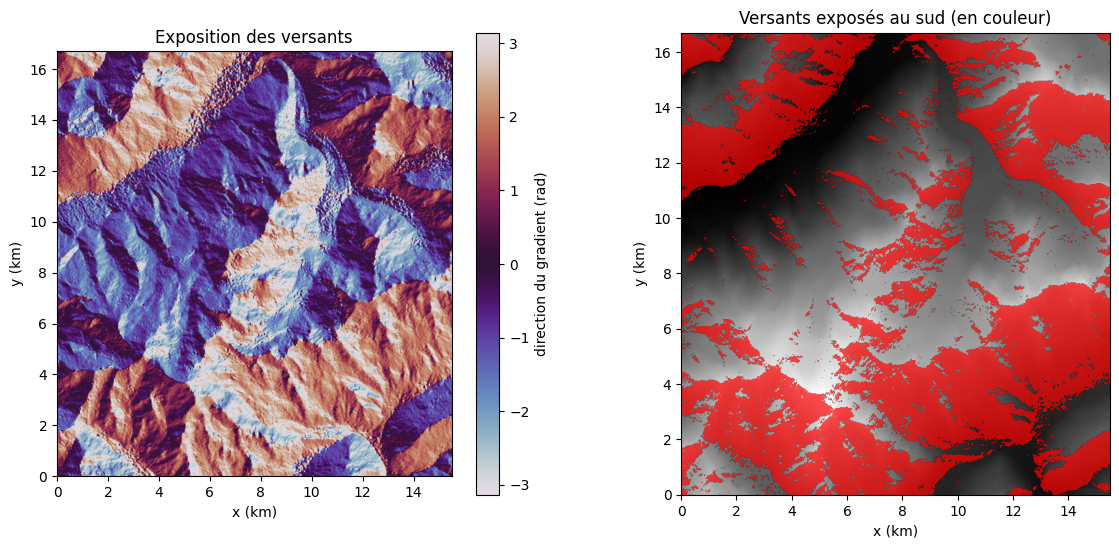

proportion de versants exposés au sud : 43 %


In [34]:
angle = np.arctan2(gy, gx)

fig, (a1, a2) = plt.subplots(1, 2, figsize=(14, 6))

im = a1.imshow(angle, origin="lower", extent=extent, cmap="twilight")
plt.colorbar(im, ax=a1, label="direction du gradient (rad)")
a1.set_title("Exposition des versants")
a1.set_xlabel("x (km)"); a1.set_ylabel("y (km)")

sud = (gy > 0) & (norme > 0.2)       # monte vers le nord => versant plein sud
a2.imshow(Z, origin="lower", extent=extent, cmap="gray")
a2.imshow(np.where(sud, 1.0, np.nan), origin="lower", extent=extent,
          cmap="autumn", alpha=0.7)
a2.set_title("Versants exposés au sud (en couleur)")
a2.set_xlabel("x (km)"); a2.set_ylabel("y (km)")
plt.show()

print("proportion de versants exposés au sud : %.0f %%" % (100 * sud.mean()))

## 3. Les points critiques: sommets, cuvettes et cols

D'après le théorème de Fermat vu en cours, en un **extremum local** le gradient s'annule:
$$
\nabla f(\vec{x}_0) = \vec{0}.
$$

Sur un terrain, les points où le gradient s'annule sont les endroits **plats**, et ils sont de trois sortes:

- un **maximum local**: un **sommet**;
- un **minimum local**: une **cuvette** (un lac, un fond de vallée fermé);
- un **point selle**: un **col** -- ça monte dans une direction et ça descend dans l'autre. C'est exactement ce qu'est un col de montagne!

<div class="alert alert-block alert-info">

**Exercice 3.1 -- où le gradient s'annule-t-il?**

- Construisez le masque des points où $\|\nabla f\| < 0{,}05$ et affichez-le par-dessus la carte.
- Combien de points obtenez-vous? Sont-ils tous des sommets ou des cols? Que représentent la plupart d'entre eux?

</div>

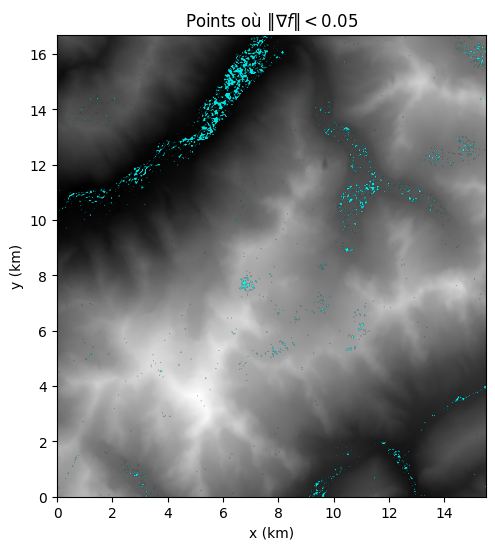

nombre de points 'plats' : 6143 sur 391324 (1.6 %)

La plupart ne sont ni des sommets ni des cols : ce sont simplement
des zones plates (glaciers, fond de vallée). Le gradient nul est une
condition NÉCESSAIRE mais pas SUFFISANTE pour avoir un extremum.


In [35]:
plat = norme < 0.05

plt.imshow(Z, origin="lower", extent=extent, cmap="gray")
plt.imshow(np.where(plat, 1.0, np.nan), origin="lower", extent=extent,
           cmap="cool", alpha=0.9)
plt.xlabel("x (km)"); plt.ylabel("y (km)")
plt.title(r"Points où $\|\nabla f\| < 0.05$")
plt.show()

print("nombre de points 'plats' : %d sur %d (%.1f %%)"
      % (plat.sum(), Z.size, 100 * plat.mean()))
print()
print("La plupart ne sont ni des sommets ni des cols : ce sont simplement")
print("des zones plates (glaciers, fond de vallée). Le gradient nul est une")
print("condition NÉCESSAIRE mais pas SUFFISANTE pour avoir un extremum.")

<div class="alert alert-block alert-info">

**Exercice 3.2 -- retrouver les sommets du massif**

Un sommet, ce n'est pas seulement un point plat: c'est un point **plus haut que tous ses voisins**.

- Lissez légèrement la carte: `Zs = gaussian_filter(Z, 2)` (pour éviter le bruit de mesure).
- Un point est un maximum local si `Zs == maximum_filter(Zs, size=41)`, c'est-à-dire s'il est le plus haut de son voisinage de 41x41 pixels (environ 1 km).
- Ne gardez que ceux au-dessus de 3500 m, affichez-les sur la carte, et listez les 6 plus hauts avec leurs coordonnées.
- Comparez aux altitudes officielles ci-dessous.

</div>

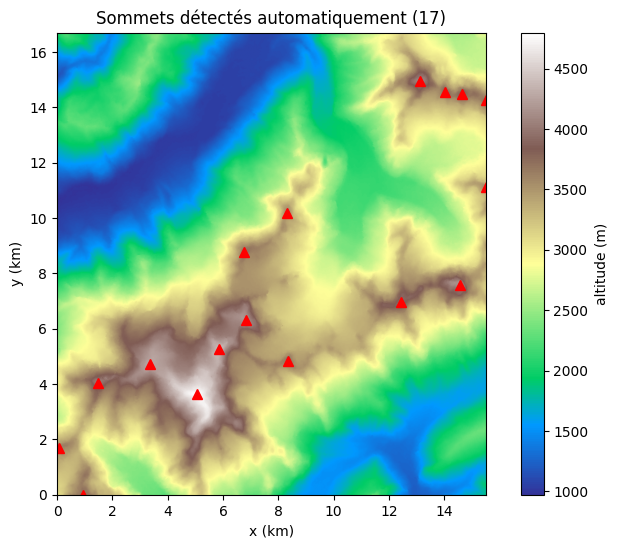

Les 6 plus hauts sommets détectés :
   4792 m   lat 45.8327   lon 6.8652
   4400 m   lat 45.8474   lon 6.8755
   4292 m   lat 45.8424   lon 6.8436
   4208 m   lat 45.8568   lon 6.8879
   4161 m   lat 45.8682   lon 6.9878
   4105 m   lat 45.9345   lon 6.9695


In [36]:
Zs = gaussian_filter(Z, 2)
sommets = (Zs == maximum_filter(Zs, size=41)) & (Z > 3500)

ii, jj = np.nonzero(sommets)
ordre  = np.argsort(-Z[ii, jj])

plt.imshow(Z, origin="lower", extent=extent, cmap="terrain")
plt.colorbar(label="altitude (m)")
plt.plot(jj * dx / 1000, ii * dy / 1000, "r^", ms=7)
plt.xlabel("x (km)"); plt.ylabel("y (km)")
plt.title("Sommets détectés automatiquement (%d)" % sommets.sum())
plt.show()

print("Les 6 plus hauts sommets détectés :")
for k in ordre[:6]:
    print("   %4.0f m   lat %.4f   lon %.4f" % (Z[ii[k], jj[k]], lat[ii[k]], lon[jj[k]]))

**Comparaison avec la réalité.** Les six sommets trouvés sont, dans l'ordre: le **Mont Blanc** (4808 m), le **Mont Maudit** (4465 m), le **Dôme du Goûter** (4304 m), le **Mont Blanc du Tacul** (4248 m), les **Grandes Jorasses** (4208 m) et l'**Aiguille Verte** (4122 m). Votre code a retrouvé tout seul la liste des 4000 du massif!

Les altitudes calculées sont systématiquement **inférieures de 20 à 150 m** aux altitudes officielles. Ce n'est pas un bug: un pixel fait 30 m de côté et contient donc une **moyenne** de l'altitude. Une arête effilée ou une pointe rocheuse est forcément lissée par la mesure. C'est une limite de la **résolution** des données, pas du calcul.

<div class="alert alert-block alert-info">

**Exercice 3.3 (bonus) -- distinguer un sommet, une cuvette et un col**

Pour classer un point critique, on regarde les **dérivées secondes**. On calcule
$$
D = \frac{\partial^2 f}{\partial x^2} \cdot \frac{\partial^2 f}{\partial y^2} - \left( \frac{\partial^2 f}{\partial x \, \partial y} \right)^{\!2}
$$
et la règle est la suivante:

| | |
|---|---|
| $D > 0$ et $\partial^2 f / \partial x^2 < 0$ | **maximum local** (sommet) |
| $D > 0$ et $\partial^2 f / \partial x^2 > 0$ | **minimum local** (cuvette) |
| $D < 0$ | **point selle** (col) |

Appliquez cette recette aux points où $\|\nabla f\| < 0{,}03$, et comptez combien il y a de sommets, de cuvettes et de cols.

</div>

points critiques : 2580
   sommets  : 439
   cuvettes : 585
   cols     : 1462


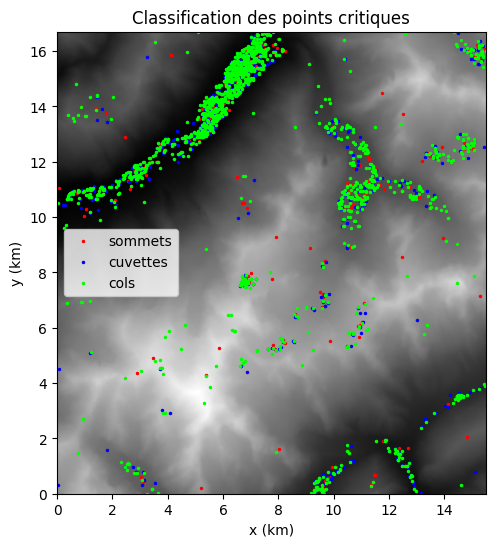

In [39]:
# dérivées secondes : on dérive une deuxième fois le gradient
gyy, gyx = np.gradient(gy, dy, dx)
gxy, gxx = np.gradient(gx, dy, dx)

D = gxx * gyy - gxy * gyx

critique = norme < 0.03
est_sommet  = critique & (D > 0) & (gxx < 0)
est_cuvette = critique & (D > 0) & (gxx > 0)
est_col     = critique & (D < 0)

print("points critiques : %d" % critique.sum())
print("   sommets  : %d" % est_sommet.sum())
print("   cuvettes : %d" % est_cuvette.sum())
print("   cols     : %d" % est_col.sum())

plt.imshow(Z, origin="lower", extent=extent, cmap="gray")
for masque, couleur, nom in [(est_sommet, "red", "sommets"),
                             (est_cuvette, "blue", "cuvettes"),
                             (est_col, "lime", "cols")]:
    a, b = np.nonzero(masque)
    plt.plot(b * dx / 1000, a * dy / 1000, ".", color=couleur, ms=3, label=nom)
plt.legend()
plt.xlabel("x (km)"); plt.ylabel("y (km)")
plt.title("Classification des points critiques")
plt.show()

## 4. Ruissellement: la descente de gradient

Une goutte d'eau posée sur le terrain suit la ligne de plus grande pente **descendante**, c'est-à-dire la direction $-\nabla f$. C'est exactement l'algorithme de **descente de gradient**:

$$
\vec{x}_{k+1} = \vec{x}_k - \eta \, \nabla f(\vec{x}_k)
$$

où $\eta > 0$ est le **pas** (en machine learning, on l'appelle le *taux d'apprentissage*).

<div class="alert alert-block alert-info">

**Exercice 4.1 -- faire tomber une goutte**

Écrivez une fonction `goutte(x0, y0, eta, n)` qui:

- part du point $(x_0, y_0)$ **exprimé en mètres**;
- répète `n` fois: convertit la position en indices (`j = round(x/dx)`, `i = round(y/dy)`), lit le gradient `gx[i, j]` et `gy[i, j]`, puis applique $\vec{x} \leftarrow \vec{x} - \eta \nabla f$;
- garde la position dans la carte avec `np.clip`;
- renvoie le tableau des positions successives.

Testez-la depuis le point $(3000, 8000)$ avec $\eta = 60$ et $n = 300$, et affichez l'altitude de départ et d'arrivée.

</div>

In [40]:
def goutte(x0, y0, eta, n=300):
    x, y = float(x0), float(y0)
    xmax = (Z.shape[1] - 1) * dx
    ymax = (Z.shape[0] - 1) * dy
    positions = [(x, y)]
    for _ in range(n):
        j = int(np.clip(round(x / dx), 0, Z.shape[1] - 1))
        i = int(np.clip(round(y / dy), 0, Z.shape[0] - 1))
        x = np.clip(x - eta * gx[i, j], 0, xmax)      # x <- x - eta * df/dx
        y = np.clip(y - eta * gy[i, j], 0, ymax)      # y <- y - eta * df/dy
        positions.append((x, y))
    return np.array(positions)


def altitude_en(x, y):
    j = int(np.clip(round(x / dx), 0, Z.shape[1] - 1))
    i = int(np.clip(round(y / dy), 0, Z.shape[0] - 1))
    return Z[i, j]


T = goutte(3000, 8000, eta=60, n=300)
print("départ  : %.0f m" % altitude_en(*T[0]))
print("arrivée : %.0f m" % altitude_en(*T[-1]))
print("distance parcourue : %.0f m" % np.hypot(*(T[-1] - T[0])))

départ  : 2447 m
arrivée : 1015 m
distance parcourue : 3296 m


<div class="alert alert-block alert-info">

**Exercice 4.2 -- une averse**

Lâchez une dizaine de gouttes depuis des points de départ différents et tracez toutes leurs trajectoires par-dessus la carte.

- Toutes les gouttes arrivent-elles au même endroit?
- Que représente le point d'arrivée d'une goutte, en termes du cours?

</div>

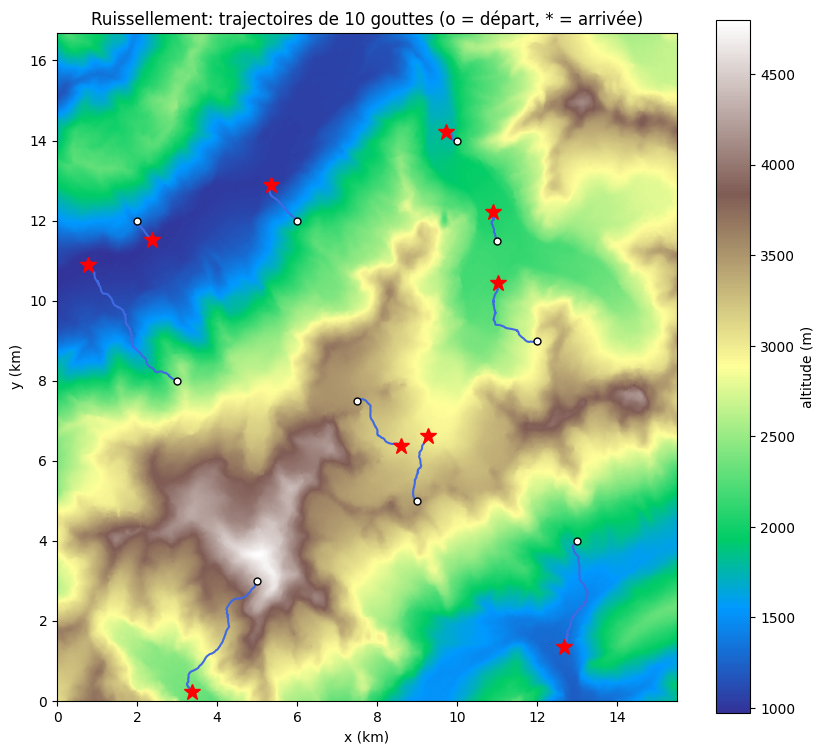

In [42]:
departs = [(3000, 8000), (6000, 12000), (9000, 5000), (12000, 9000),
           (5000, 3000), (10000, 14000), (2000, 12000), (13000, 4000),
           (7500, 7500), (11000, 11500)]

plt.figure(figsize=(10, 9))
plt.imshow(Z, origin="lower", extent=extent, cmap="terrain")
plt.colorbar(label="altitude (m)")

for (x0, y0) in departs:
    T = goutte(x0, y0, eta=60, n=400)
    plt.plot(T[:, 0] / 1000, T[:, 1] / 1000, "-", color="royalblue", lw=1.5)
    plt.plot(T[0, 0] / 1000, T[0, 1] / 1000, "o", color="white", ms=5, mec="k")
    plt.plot(T[-1, 0] / 1000, T[-1, 1] / 1000, "*", color="red", ms=12)

plt.xlabel("x (km)"); plt.ylabel("y (km)")
plt.title("Ruissellement: trajectoires de 10 gouttes (o = départ, * = arrivée)")
plt.show()

**Réponse.** Non, les gouttes n'arrivent pas toutes au même endroit: chacune tombe dans la cuvette la plus proche. Le point d'arrivée est un **minimum local** de l'altitude, atteint lorsque $\nabla f = \vec{0}$ et que la goutte ne bouge plus.

C'est exactement le problème central du machine learning: la descente de gradient trouve **un** minimum local, pas nécessairement le minimum global. Le résultat dépend du point de départ -- d'où l'importance de l'initialisation quand on entraîne un modèle.

<div class="alert alert-block alert-info">

**Exercice 4.3 -- l'influence du pas $\eta$**

Reprenez le même point de départ $(3000, 8000)$ et comparez les trajectoires pour $\eta = 5$, $\eta = 60$, $\eta = 3000$ et $\eta = 8000$.

Pour chacune, affichez l'altitude d'arrivée et la longueur moyenne des 50 derniers pas. Que se passe-t-il quand $\eta$ est trop petit? Trop grand?

</div>

eta =     5 : arrivée à 1755 m, pas moyen des 50 derniers =      3 m
eta =    60 : arrivée à 1015 m, pas moyen des 50 derniers =      6 m
eta =  3000 : arrivée à  995 m, pas moyen des 50 derniers =    207 m
eta =  8000 : arrivée à 3069 m, pas moyen des 50 derniers =      0 m


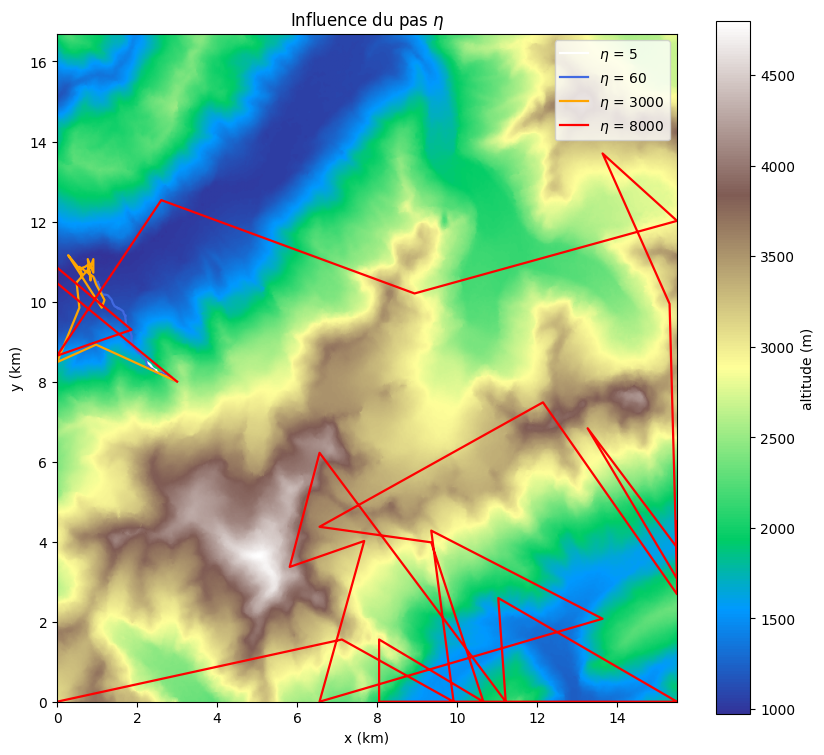

In [43]:
plt.figure(figsize=(10, 9))
plt.imshow(Z, origin="lower", extent=extent, cmap="terrain")
plt.colorbar(label="altitude (m)")

for eta, couleur in [(5, "white"), (60, "royalblue"), (3000, "orange"), (8000, "red")]:
    T = goutte(3000, 8000, eta=eta, n=300)
    pas = np.hypot(*(T[1:] - T[:-1]).T)
    plt.plot(T[:, 0] / 1000, T[:, 1] / 1000, "-", color=couleur, lw=1.6,
             label=r"$\eta$ = %d" % eta)
    print("eta = %5d : arrivée à %4.0f m, pas moyen des 50 derniers = %6.0f m"
          % (eta, altitude_en(*T[-1]), pas[-50:].mean()))

plt.legend()
plt.xlabel("x (km)"); plt.ylabel("y (km)")
plt.title(r"Influence du pas $\eta$")
plt.show()

**Réponse.**

- $\eta = 5$: la goutte avance par pas minuscules et n'a **pas eu le temps** d'atteindre le fond après 300 itérations. Trop lent.
- $\eta = 60$: la goutte descend franchement puis se stabilise, les derniers pas deviennent tout petits. C'est le bon régime.
- $\eta = 3000$: la goutte **saute par-dessus** le fond de la vallée et oscille d'un versant à l'autre sans jamais se stabiliser: les derniers pas restent grands.
- $\eta = 8000$: c'est pire, la goutte est carrément éjectée de son bassin versant et finit bloquée sur un replat glaciaire, 2000 m plus haut que le fond de vallée.

C'est très exactement le compromis sur le **taux d'apprentissage** en machine learning: trop petit, l'entraînement n'en finit pas; trop grand, il diverge.

## Conclusion

Sur une simple carte d'altitude, vous avez manipulé:

- la **dérivée** comme taux d'accroissement, et ses limites en calcul numérique (la courbe en V);
- les **dérivées partielles** et le **gradient** d'une fonction de deux variables;
- le fait que le gradient est **perpendiculaire aux courbes de niveau** et pointe vers le haut;
- les **points critiques** ($\nabla f = \vec{0}$): sommets, cuvettes et cols, et le fait que $\nabla f = \vec 0$ est nécessaire mais pas suffisant;
- la **descente de gradient**, ses minima locaux et le réglage du pas.

**Pour aller plus loin.** Dans la suite du cours, la fonction $f$ ne sera plus une altitude mais une **fonction de coût** $L(\vec{w})$ qui mesure l'erreur d'un modèle, et les coordonnées $\vec{w}$ ne seront plus une position sur une carte mais les **paramètres** du modèle. L'algorithme, lui, sera rigoureusement le même que celui de l'exercice 4.1.